In [1]:
!hostname

node1415


In [2]:
#import gizmo_analysis as gizmo
#import utilities as ut
import matplotlib as mpl
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib import colors

import os
os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'
import h5py


from IPython.utils import io

# plt.style.use('/home/zeinebm/latex_plot_style.mplstyle')

# Define input conditions

In [ ]:
# g1 = h5py.File('/home/zeinebm/Results/Gal1/snap_010.hdf5','r')
# g2 = h5py.File('/home/zeinebm/Results/G00/snap_010.hdf5','r')

g1 = h5py.File #change to the host #('/pool001/zeinebm/sim/MW_gal/snap_010.hdf5','r')
g2 = h5py.File # change to the satellite #('/pool001/zeinebm/sim/GSE_gal/snap_010.hdf5','r')

Define the following as integers since they are used in filename...

In [ ]:
g1_xyz_start = np.array([0, 0, 0])
g1_vxyz_start = np.array([0, 0, 0])

g2_xyz_start= #change to the ics wanted: np.array([-124.604, 0, -33.3877])
g2_vxyz_start =#change to the ics wanted:  np.array([119.715, 45.6084, -15.1398])

# for G0: [154.87804/1.023, 2.8638382/1.023, -42.79063/1.023])

#/1.023

# Shift gal1 and gal2 to their specified initial position and velocity

In [5]:
g1_part1_coords = g1['PartType1']['Coordinates'] + g1_xyz_start
g1_part1_vels = g1['PartType1']['Velocities'] + g1_vxyz_start
g1_part1_mass = g1['PartType1']['Masses'][:]
g1_part1_ids = g1['PartType1']['ParticleIDs'][:]

g1_part2_coords = g1['PartType2']['Coordinates'] + g1_xyz_start
g1_part2_vels = g1['PartType2']['Velocities'] + g1_vxyz_start
g1_part2_mass = g1['PartType2']['Masses'][:]
g1_part2_ids = g1['PartType2']['ParticleIDs'][:]

g1_part3_coords = g1['PartType3']['Coordinates'] + g1_xyz_start
g1_part3_vels = g1['PartType3']['Velocities'] + g1_vxyz_start
g1_part3_mass = g1['PartType3']['Masses'][:]
g1_part3_ids = g1['PartType3']['ParticleIDs'][:]


In [6]:
g2_part1_coords = g2['PartType1']['Coordinates'] + g2_xyz_start
g2_part1_vels = g2['PartType1']['Velocities'] + g2_vxyz_start
g2_part1_mass = g2['PartType1']['Masses'][:]
g2_part1_ids = g2['PartType1']['ParticleIDs'][:]

#changed to part3 when the stars are in the buldge now 
#np.array([]) 
#change to empty arrays when using adri's satellites 

g2_part2_coords = g2['PartType2']['Coordinates'] + g2_xyz_start
g2_part2_vels =  g2['PartType2']['Velocities'] + g2_vxyz_start
g2_part2_mass = g2['PartType2']['Masses'][:]
g2_part2_ids =  g2['PartType2']['ParticleIDs'][:]

# plt. scatter(g2_part1_coords[:,0], g2_part1_coords[:,1])

# Shift gal1 and gal2 to the COM and COV frame

In [7]:
g1_part1_coords_cm = g1_part1_coords #- Rcm
g1_part2_coords_cm = g1_part2_coords #- Rcm
g1_part3_coords_cm = g1_part3_coords #- Rcm

g1_part1_vels_cm = g1_part1_vels #- Vcm
g1_part2_vels_cm = g1_part2_vels #- Vcm
g1_part3_vels_cm = g1_part3_vels

In [8]:
print(len(g1_part1_coords))
print(len(g2_part1_coords))

print("tot = ", len(g1_part1_coords) + len(g2_part1_coords))

15149000
6797450
tot =  21946450


In [9]:
#wrt to host frame: 

g2_part1_coords_hf = g2_part1_coords #+ g2_xyz_start
g2_part2_coords_hf= g2_part2_coords #+ g2_xyz_start

g2_part1_vels_hf = g2_part1_vels #+ g2_vxyz_start
g2_part2_vels_hf = g2_part2_vels #+ g2_vxyz_start

# Join up the files and align Particle IDs

In [10]:
g1_ndm = len(g1_part1_ids)
g1_ndisk = len(g1_part2_ids) 
g1_nbulge = len(g1_part3_ids)
print(g1_ndm, g1_ndisk, g1_nbulge)

g2_ndm = len(g2_part1_ids)
g2_ndisk = len(g2_part2_ids)
print(g2_ndm, g2_ndisk)

15149000 189362 441845
6797450 15834


In [11]:
g1_part1_ids_join = g1_part1_ids
g1_part2_ids_join = g1_part2_ids
g1_part3_ids_join = g1_part3_ids
g2_part1_ids_join = g2_part1_ids + g1_ndm + g1_ndisk + g1_nbulge
g2_part2_ids_join = g2_part2_ids + g1_ndm + g1_ndisk + g1_nbulge

print(len(g1_part2_ids_join)+len(g1_part3_ids_join), len(g2_part2_ids_join ))

631207 15834


In [18]:


print(g1_part1_ids[: -10])

print(g2_part1_ids[: -10])


[       1        2        3 ... 15769675 15769676 15769677]
[      1       2       3 ... 6813009 6813010 6813011]


(0.0, 1500.0)

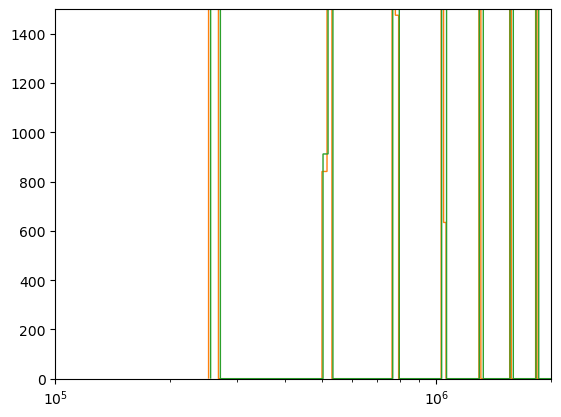

In [12]:
plt.hist(g1_part1_ids_join, bins=1000, histtype='step')
plt.hist(g1_part2_ids_join, bins=1000, histtype='step')
plt.hist(g1_part3_ids_join, bins=1000, histtype='step')
plt.hist(g2_part1_ids_join, bins=1000, histtype='step')
plt.hist(g2_part2_ids_join, bins=1000, histtype='step')
plt.xscale('log')
plt.xlim([1e5, 2e6])
plt.ylim([0, 1500])

# Concatenate gal1 and gal2 arrays

In [12]:
part1_coords = np.concatenate((g1_part1_coords_cm, g2_part1_coords_hf))

#change this when for Adri's satellites:
# g1_part2_coords_cm   
part2_coords = np.concatenate((g1_part2_coords_cm, g2_part2_coords_hf))

part3_coords =g1_part3_coords_cm
print(len(part1_coords), len(part2_coords),len(part3_coords))

21946450 205196 441845


In [17]:
part1_vels = np.concatenate((g1_part1_vels_cm, g2_part1_vels_hf))

#this changes for Adri's sats
# g1_part2_vels_cm
part2_vels = np.concatenate((g1_part2_vels_cm, g2_part2_vels_hf))

part3_vels =g1_part3_vels_cm
print(len(part1_vels), len(part2_vels), len(part3_vels))

21946450 205196 441845


In [13]:
part1_ids = np.concatenate((g1_part1_ids_join, g2_part1_ids_join))
part2_ids = np.concatenate((g1_part2_ids_join, g2_part2_ids_join))
part3_ids = g1_part3_ids_join
print(len(part1_ids), len(part2_ids), len(part3_ids))


21946450 205196 441845


In [14]:
part1_mass = np.concatenate((g1_part1_mass, g2_part1_mass))
part2_mass = np.concatenate((g1_part2_mass, g2_part2_mass))
part3_mass = g1_part3_mass
print(len(part1_mass), len(part2_mass), len(part3_mass))

21946450 205196 441845


In [15]:
print("DM particle mass in the host: ", g1_part1_mass[1])
print("DM particle mass in the satellite: ", g2_part1_mass[1])

print("star mass in the host disk: ", g1_part2_mass[1])
print("star mass in the host bulge: ", g1_part3_mass[1])
print("star mass in the satellite: ", g2_part2_mass[1])

DM particle mass in the host:  3.1622706e-06
DM particle mass in the satellite:  3.1622774e-06
star mass in the host disk:  3.162279e-06
star mass in the host bulge:  3.1622765e-06
star mass in the satellite:  3.162292e-06


(0.0, 1500.0)

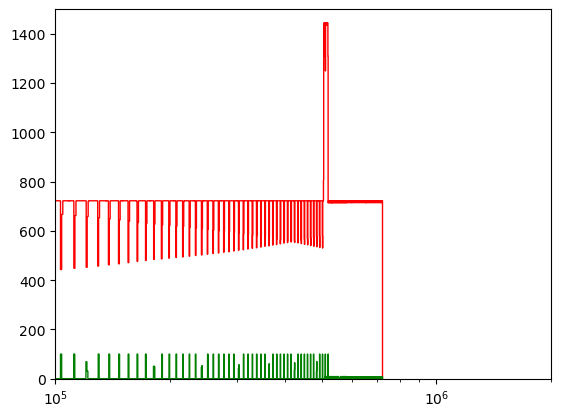

In [23]:
plt.hist(part1_ids, bins=1000, histtype='step', color='red')
plt.hist(part2_ids, bins=1000, histtype='step', color='green')
plt.xscale('log')
plt.xlim([1e5, 2e6])
plt.ylim([0, 1500])

In [25]:
# plt.hist(part1_coords[:,2], range=(-200,200), bins=100)
# plt.hist(part2_coords[:,2], range=(-200,200), bins=100)
# plt.show()
part2_coords.shape

(205196, 3)

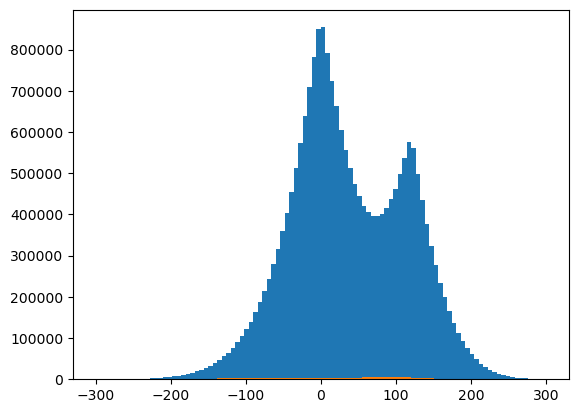

In [18]:
plt.hist(part1_vels[:,0], range=(-300,300), bins=100)
plt.hist(part2_vels[:,0], range=(-300,300), bins=100)
plt.show()

# Save to hdf5 file

In [27]:
import astropy
import astropy.io.fits

In [ ]:
directory = # incldue the direcoty of the porject

output_filename = 'ics.hdf5'
print(directory)
print(output_filename)

/pool001/zeinebm/sim/CDM/
ics.hdf5


In [29]:
if os.path.exists(directory + output_filename):
    os.remove(directory + output_filename)
else:
    print("Cannot delete the file as it does not exist")

In [30]:
file = h5py.File(directory + output_filename, 'w')

In [31]:
npart = np.array([0,g1_ndm + g2_ndm, g1_ndisk+g2_ndisk,g1_nbulge,0,0])
print(npart)

[       0 21946450   205196   441845        0        0]


In [32]:
h = file.create_group('Header')
h.attrs['NumPart_ThisFile'] = npart   
h.attrs['NumPart_Total'] = npart                  
h.attrs['NumPart_Total_HighWord'] = 0*npart 

## everything below this point will just be written over
## need to set values for the code to read

h.attrs['MassTable'] = np.zeros(6)
h.attrs['Time'] = 0.0  
h.attrs['Redshift'] =  2
h.attrs['BoxSize'] = 1.0 
h.attrs['NumFilesPerSnapshot'] = 1                                      
h.attrs['Omega0'] = 0.3
h.attrs['OmegaLambda'] = 0.7 
h.attrs['HubbleParam'] = 0.7                                                                    
h.attrs['Flag_Sfr'] = 0 
h.attrs['Flag_Cooling'] = 0 
h.attrs['Flag_StellarAge'] = 0 
h.attrs['Flag_Metals'] = 0 
h.attrs['Flag_Feedback'] = 0 
h.attrs['Flag_DoublePrecision'] = 0
h.attrs['Flag_IC_Info'] = 0

In [33]:
p1 = file.create_group('PartType1')
p1.create_dataset('Coordinates', data=part1_coords)
p1.create_dataset('Velocities', data=part1_vels)
p1.create_dataset('ParticleIDs', data=part1_ids)
p1.create_dataset('Masses', data=part1_mass)

<HDF5 dataset "Masses": shape (21946450,), type "<f4">

In [34]:
p2 = file.create_group('PartType2')
p2.create_dataset('Coordinates', data=part2_coords)
p2.create_dataset('Velocities', data=part2_vels)
p2.create_dataset('ParticleIDs', data=part2_ids)
p2.create_dataset('Masses', data=part2_mass)

<HDF5 dataset "Masses": shape (205196,), type "<f4">

In [35]:
p3 = file.create_group('PartType3')
p3.create_dataset('Coordinates', data=part3_coords)
p3.create_dataset('Velocities', data=part3_vels)
p3.create_dataset('ParticleIDs', data=part3_ids)
p3.create_dataset('Masses', data=part3_mass)

<HDF5 dataset "Masses": shape (441845,), type "<f4">

In [32]:
file.close()

In [19]:
g1.close()
g2.close()